# Baseline notebook

Create model baseline and analysis for it

In [1]:
import pandas as pd 
import numpy as np

pd.set_option('display.max_columns', 200)
np.random.seed(42)

In [2]:
%pip install -q kagglehub

In [3]:
# download dataset from kaggle
import kagglehub # pyright: ignore[reportMissingImports]
from pathlib import Path

# Download latest version
path = Path(kagglehub.dataset_download("blastchar/telco-customer-churn"))
path = path / r"WA_Fn-UseC_-Telco-Customer-Churn.csv"

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
df = pd.read_csv(path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data preparation (From EDA)

In [5]:
to_category_columns = (
    [
        "gender",
        "Partner",
        "Dependents",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup", 
        "DeviceProtection",
        "TechSupport",
        "StreamingTV", 
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "Churn"
        ])
    
for column in to_category_columns:
    df[column] = df[column].astype("category")
    
df["SeniorCitizen"] = df["SeniorCitizen"] == 1
df["Churn"] = df["Churn"] == "Yes"
    
df["TotalCharges"]  = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna()
df["TotalCharges"].isna().sum()


# Drop customerId column as never significant
df = df.drop(columns="customerID")
df.shape

print("Data preparation is done")
df.shape

Data preparation is done


(7032, 20)

## Model building

In [6]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
from sklearn.preprocessing import LabelEncoder # type: ignore

df_ohe = pd.get_dummies(df)
df_ohe.shape

(7032, 46)

In [8]:
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, average_precision_score
from sklearn.ensemble import RandomForestClassifier

X = df_ohe.drop(columns="Churn").copy()
y = df_ohe["Churn"].copy()

rf = RandomForestClassifier(random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(rf, X, y, cv=skf)
y_proba_cv = cross_val_predict(rf, X, y, cv=skf, method="predict_proba")[:, 1]
auc_scores = cross_val_score(rf, X, y, cv=skf, scoring='average_precision')
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_scores.mean():.4f} +/- {auc_scores.std():.4f} (var: {auc_scores.var():.4f})")

              precision    recall  f1-score   support

       False       0.83      0.90      0.86      5163
        True       0.64      0.48      0.55      1869

    accuracy                           0.79      7032
   macro avg       0.73      0.69      0.70      7032
weighted avg       0.78      0.79      0.78      7032

PR-AUC: 0.6107 +/- 0.0184 (var: 0.0003)


### Metrics explained

It simpler to explain on one class. I will use where Churn is True

Class True (Churn is True):
- Precision 0.64 — when model predicts "churn", it's correct only 64% of the time
- Recall 0.48 — it catches only 48% of actual churners
- PR-AUC 0.6107 - how model is confident in class splitting. Will the customer with the biggest confidence actually churned one. (Add standard deviation for deep comparing)

Same logic for the not churned users

As we are trying to minimize missing churns (FN error that costs business big money). We should maximize recall on True class.

Despite model performs well on false classes (can classify not churning customers) it's perform nearly a coin flip predict on actually churned ones. Such conduct can be caused by class imbalance (roughly $\approx30%$% customers from data were churned)

## Data imbalance handling

Let's evaluate class imbalance handling methods

In [9]:
churn_ratio = df_ohe.groupby("Churn")["Churn"].count()
churn_ratio

,Churn
Churn,
False,5163
True,1869


In [10]:
print(f"Churned to not churned ratio is {churn_ratio.iloc[1] / churn_ratio.iloc[0]:.2f}")

Churned to not churned ratio is 0.36


### Model tuning (class_weight = 'balanced')

In [11]:
# Simply change parameter in model
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(rf, X, y, cv=skf)
y_proba_cv = cross_val_predict(rf, X, y, cv=skf, method="predict_proba")[:, 1]
auc_scores = cross_val_score(rf, X, y, cv=skf, scoring='average_precision')
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_scores.mean():.4f} +/- {auc_scores.std():.4f} (var: {auc_scores.var():.4f})")

              precision    recall  f1-score   support

       False       0.83      0.90      0.86      5163
        True       0.64      0.48      0.55      1869

    accuracy                           0.79      7032
   macro avg       0.73      0.69      0.71      7032
weighted avg       0.78      0.79      0.78      7032

PR-AUC: 0.6148 +/- 0.0141 (var: 0.0002)


Metrics do not change significantly. Thats common issue with decision tree models and [documented](https://stackoverflow.com/questions/30972029/how-does-the-class-weight-parameter-in-scikit-learn-work). TL;DR class weight affect node splitting criteria and typically produce no significant changes 

### Using GBDT model

I will train a LightGBM as GBDT model with `scale_pos_weight` parameter that prioritize minor class by custom scale. 

The basic scale formula is $\text{scale}=\frac{\text{Number of negative samples}}{\text{Number of positive samples}}$ 

In [12]:
%pip install lightgbm -q

In [13]:
import lightgbm as lgb

minor_base_scale = churn_ratio.iloc[0] / churn_ratio.iloc[1]
lgbm = lgb.LGBMClassifier(scale_pos_weight=minor_base_scale, verbose=-1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(lgbm, X, y, cv=skf)
y_proba_cv = cross_val_predict(lgbm, X, y, cv=skf, method="predict_proba")[:, 1]
auc_scores = cross_val_score(lgbm, X, y, cv=skf, scoring='average_precision')
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_scores.mean():.4f} +/- {auc_scores.std():.4f} (var: {auc_scores.var():.4f})")

              precision    recall  f1-score   support

       False       0.89      0.76      0.82      5163
        True       0.53      0.75      0.62      1869

    accuracy                           0.76      7032
   macro avg       0.71      0.75      0.72      7032
weighted avg       0.80      0.76      0.77      7032

PR-AUC: 0.6533 +/- 0.0139 (var: 0.0002)


GBDT with native data imbalance handling parameter performs much better than random forest. We gain 75% recall on our churned customers that is good result for almost not tuned model. GBDT is slightly more confident in splitting as AUC score have increased by 5% compared to baseline

### Undersampling

In [14]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

X = df_ohe.drop(columns="Churn").copy()
y = df_ohe["Churn"].copy()

pipeline = Pipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=skf)
y_proba_cv = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")[:, 1]
auc_scores = cross_val_score(pipeline, X, y, cv=skf, scoring='average_precision')
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_scores.mean():.4f} +/- {auc_scores.std():.4f} (var: {auc_scores.var():.4f})")

              precision    recall  f1-score   support

       False       0.89      0.73      0.80      5163
        True       0.51      0.76      0.61      1869

    accuracy                           0.74      7032
   macro avg       0.70      0.74      0.71      7032
weighted avg       0.79      0.74      0.75      7032

PR-AUC: 0.6110 +/- 0.0132 (var: 0.0002)


Undersampled metrics are quite impressive. We achieve score like a GBDT model but using baseline. Undersample have decrease metrics on False classes (Model do more FP mistakes, thinking that customer will churn, while he will not). For our case this is acceptable (we are focusing on detecting True classes). Splitting confidence at the same level as baseline, cause AUC do not significantly changed

### Oversampling

#### Bootstrap oversampling

Oversampling that will simply bootstrap minority class

In [15]:
from imblearn.over_sampling import RandomOverSampler

X = df_ohe.drop(columns="Churn").copy()
y = df_ohe["Churn"].copy()

pipeline = Pipeline([
    ("oversample", RandomOverSampler(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=skf)
y_proba_cv = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")[:, 1]
auc_scores = cross_val_score(pipeline, X, y, cv=skf, scoring='average_precision')
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_scores.mean():.4f} +/- {auc_scores.std():.4f} (var: {auc_scores.var():.4f})")

              precision    recall  f1-score   support

       False       0.85      0.86      0.85      5163
        True       0.59      0.58      0.59      1869

    accuracy                           0.78      7032
   macro avg       0.72      0.72      0.72      7032
weighted avg       0.78      0.78      0.78      7032

PR-AUC: 0.5998 +/- 0.0150 (var: 0.0002)


Bootstrap oversampling also increase our metrics on True class recall/precision. But we must note that AUC score decreased comparing to baseline. Model can tender to give high probabilities for not churning customers (and thats important)

#### SMOTE (SMOTENC) oversampling

Interpolate points to balance minority class

SMOTENC is a modification that handles mixed numerical and categorical features natively, so it works directly on the original dataframe

In [16]:
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X = df.drop(columns="Churn").copy()
y = df["Churn"].copy()

cat_cols = X.select_dtypes(include=["category", "bool"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols),
], remainder="passthrough").set_output(transform="pandas")

pipeline = Pipeline([
    ("smotenc", SMOTENC(categorical_features=cat_cols, random_state=42)),
    ("preprocessor", preprocessor),
    ("rf", RandomForestClassifier(random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=skf)
y_proba_cv = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")[:, 1]
auc_scores = cross_val_score(pipeline, X, y, cv=skf, scoring='average_precision')
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_scores.mean():.4f} +/- {auc_scores.std():.4f} (var: {auc_scores.var():.4f})")

              precision    recall  f1-score   support

       False       0.85      0.85      0.85      5163
        True       0.58      0.58      0.58      1869

    accuracy                           0.78      7032
   macro avg       0.71      0.71      0.71      7032
weighted avg       0.78      0.78      0.78      7032

PR-AUC: 0.5913 +/- 0.0087 (var: 0.0001)


SMOTE give us metrics similar to bootstrapping oversample. The cause might be in our data. The data is mostly categorical with only 3 numeric features. Interpolation between points [use KNN (k nearest neighbors)](https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/) (See SMOTENC topic) and mostly duplicates categorical features causing bootstrapping with noise in numeric features. AUC near the bootstrapping approach

### GBDT + undersampling

In [17]:
X = df_ohe.drop(columns="Churn").copy()
y = df_ohe["Churn"].copy()

pipeline = Pipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("lgb", lgb.LGBMClassifier(verbose=-1))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=skf)
y_proba_cv = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")[:, 1]
auc_scores = cross_val_score(pipeline, X, y, cv=skf, scoring='average_precision')
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_scores.mean():.4f} +/- {auc_scores.std():.4f} (var: {auc_scores.var():.4f})")

              precision    recall  f1-score   support

       False       0.90      0.72      0.80      5163
        True       0.50      0.77      0.61      1869

    accuracy                           0.74      7032
   macro avg       0.70      0.75      0.70      7032
weighted avg       0.79      0.74      0.75      7032

PR-AUC: 0.6317 +/- 0.0125 (var: 0.0002)


GBDT with undersampling slightly improved our recall and decrease precision

But AUC score is lower than GBDT model approach itself. Do not see the point of using this approach

## Conclusion

Plot of experiments for better analysis experience

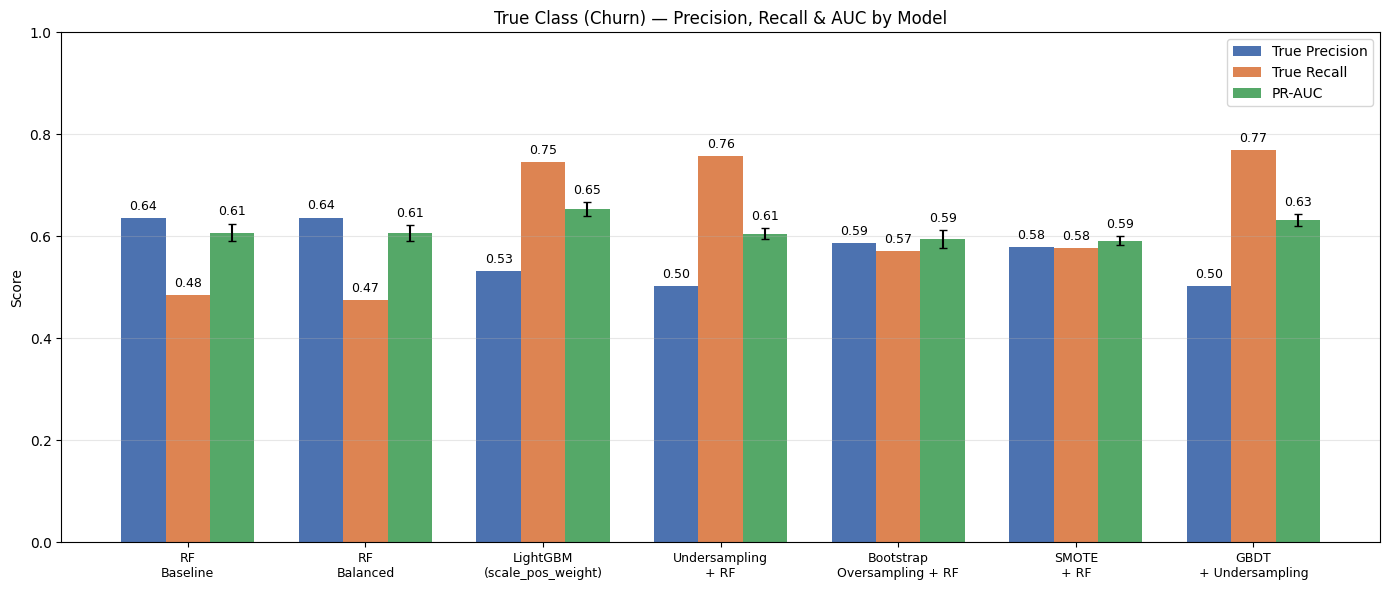

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import cross_val_score

X = df.drop(columns="Churn").copy()
y = df["Churn"].copy()

cat_features = X.select_dtypes(include=["category", "bool"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_features),
], remainder="passthrough").set_output(transform="pandas")

model_configs = {
    "RF\nBaseline": Pipeline([
        ("preprocessor", preprocessor),
        ("rf",RandomForestClassifier(random_state=42)),
    ]),
    "RF\nBalanced": Pipeline([
        ("preprocessor", preprocessor),
        ("rf",RandomForestClassifier(random_state=42, class_weight="balanced")),
    ]),
    "LightGBM\n(scale_pos_weight)": Pipeline([
        ("preprocessor", preprocessor),
        ("lgb",lgb.LGBMClassifier(scale_pos_weight=minor_base_scale, verbose=-1)),
        ]),
    "Undersampling\n+ RF": Pipeline([
        ("preprocessor", preprocessor),
        ("undersample", RandomUnderSampler(random_state=42)),
        ("rf", RandomForestClassifier(random_state=42)),
    ]),
    "Bootstrap\nOversampling + RF": Pipeline([
        ("preprocessor", preprocessor),
        ("oversample", RandomOverSampler(random_state=42)),
        ("rf", RandomForestClassifier(random_state=42)),
    ]),
    "SMOTE\n+ RF": Pipeline([
        ("smotenc", SMOTENC(categorical_features=cat_cols, random_state=42)),
        ("preprocessor", preprocessor),
        ("rf", RandomForestClassifier(random_state=42)),
    ]),
    "GBDT\n+ Undersampling": Pipeline([
        ("preprocessor", preprocessor),
        ("undersample", RandomUnderSampler(random_state=42)),
        ("lgb", lgb.LGBMClassifier(verbose=-1)),
    ]),
}

model_names = []
true_precision = []
true_recall = []
true_auc_mean = []
true_auc_std = []

for name, model in model_configs.items():
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_cv = cross_val_predict(model, X, y, cv=skf)
    auc_scores = cross_val_score(model, X, y, cv=skf, scoring='average_precision')
    
    model_names.append(name)
    true_precision.append(precision_score(y, y_pred_cv))
    true_recall.append(recall_score(y, y_pred_cv))
    true_auc_mean.append(auc_scores.mean())
    true_auc_std.append(auc_scores.std())

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, true_precision, width, label="True Precision", color="#4C72B0")
bars2 = ax.bar(x, true_recall, width, label="True Recall", color="#DD8452")
bars3 = ax.bar(x + width, true_auc_mean, width, yerr=true_auc_std, capsize=3, label="PR-AUC", color="#55A868")

ax.set_ylabel("Score")
ax.set_title("True Class (Churn) — Precision, Recall & AUC by Model")
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for i, bar in enumerate(bars3):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + true_auc_std[i] + 0.01, f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


From plot we see that best approaches are using GBDT model with imbalance param or using an udersample technic on random forest

But all our manipulations with data decrease model precision from 0.68 to ~0.5. That means if model predict 10 churned people 5 will be actually churn. That leads to big potential losses on FP errors ($\approx90$ $) and should be threated with PR-ROC curve analysis

### Taking a look on PR-AUC curves

Note: no cross validation there. Metrics are not same as crossvalidated (slightly noisier)

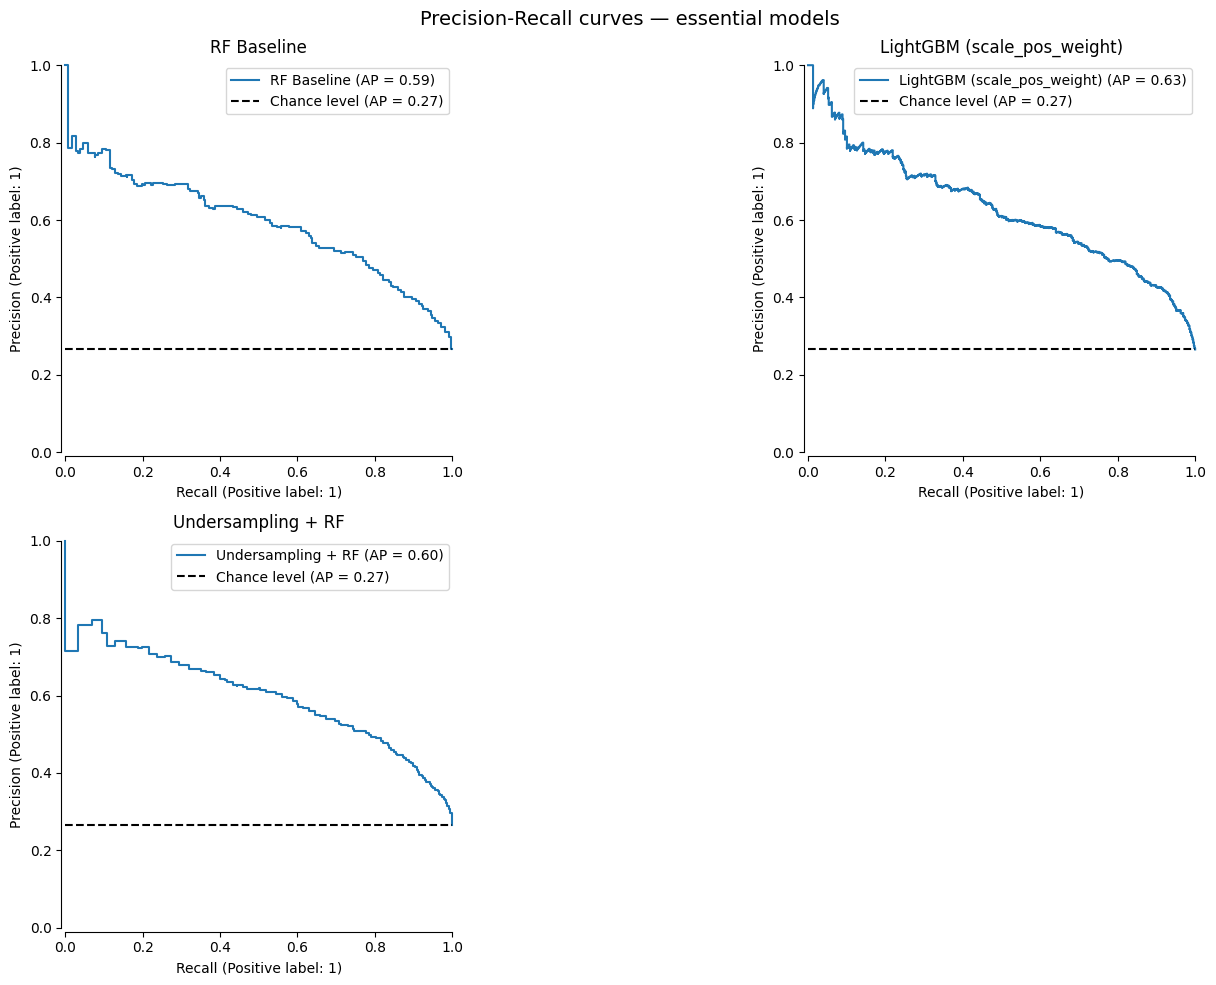

In [19]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X = df_ohe.drop(columns="Churn").copy()
y = df_ohe["Churn"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y)

models = {
    "RF Baseline": RandomForestClassifier(random_state=42),
    "LightGBM (scale_pos_weight)": lgb.LGBMClassifier(scale_pos_weight=minor_base_scale, verbose=-1),
    "Undersampling + RF": Pipeline([
        ("us", RandomUnderSampler(random_state=42)),
        ("rf", RandomForestClassifier(random_state=42)),
    ]),
    "Bootstrap Oversampling + RF": Pipeline([
        ("os", RandomOverSampler(random_state=42)),
        ("rf", RandomForestClassifier(random_state=42)),
    ]),
}

n = len(models)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_test)[:, 1]
    PrecisionRecallDisplay.from_predictions(
        y_test, y_score, name=name, ax=ax, plot_chance_level=True, despine=True)
    ax.set_title(name)
    ax.legend(loc="best")

axes[-1].set_visible(False)
fig.suptitle("Precision-Recall curves — essential models", fontsize=14)
plt.tight_layout()
plt.show()

From the curves we can see that baselines are definitely better than coin flips (black line at 0.27 "Chance level"). Also I can mention that we can achieve $\approx0.7$ precision with $\approx0.2$ recall or $\approx0.8-1.0$ with $\approx[0.25;0.4]$ precision.
The middle give us 0.6 precision with $[0.4-0.6]$ recall

That means that we can build ether confident model with ~70% confidence in catching churns (but it will catch only 20% of churned customers). Or we can build a model that will catch 80-100% of churns but will have many false predictions (only 25-40% predictions will be true)

Achieving a model with ~60% churn coverage will not significant affect precision (~60% of true predictions)

### PR curve in real cash (theoretically)

Lets adjust classification threshold for basic model
Note: Look that PR-curves are mostly identical. So the calculations below will be similar for them

Next curve will estimate TP, FP and FN error in real money.

Recall costs:
- FN cost us (real leaving customer) $997.94$ $ 
- FP (give a discount to not leaving customer) cost us $89.33$ $

Also my lines are plotted with a notion that retention company do not have 100% success for customer

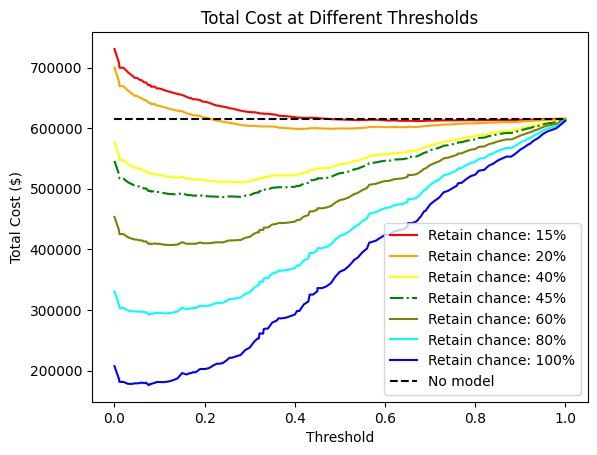

In [20]:
from sklearn.metrics import precision_recall_curve

rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)
y_score = rf_baseline.predict_proba(X_test)[:, 1]

FN_cost = 997.94
FP_cost = 89.33
retain_p = [0.15, 0.20, 0.4, 0.45, 0.6, 0.8, 1]
p_line_col = ["red", "orange","yellow", "green", "olive", "cyan", "blue"]

precision, recall, thresholds = precision_recall_curve(y_test, y_score)
total_costs = []
# real churned customers from dataset
P = y_test.sum()

for p in retain_p:
    p_thd_costs = []
    for i in range(len(thresholds)):
        TP = recall[i] * P
        FN = P - TP
        FP = TP * (1 / precision[i] - 1)   # precision = TP / (TP + FP)
        
        cost_tp = FP_cost + (1-p)*FN_cost
        # True positive prediction cost us
        # Retention company price (we give it for all churn customers)
        # And with 1-p probability we are loosing client 
        
        p_thd_costs.append(FN * FN_cost + FP_cost*FP+cost_tp*TP)
        
    total_costs.append(p_thd_costs)

for i, line_costs in enumerate(total_costs): 
    if retain_p[i] == 0.45:
        plt.plot(thresholds, line_costs, label=f"Retain chance: {retain_p[i]*100:.0f}%", color=p_line_col[i], linestyle="-.")
    else:
        plt.plot(thresholds, line_costs, label=f"Retain chance: {retain_p[i]*100:.0f}%", color=p_line_col[i])

# No model baseline — predict no one as churned
no_model_cost = [P * FN_cost] * len(thresholds)
plt.plot(thresholds, no_model_cost, label="No model", color="black", linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Total Cost ($)")
plt.title("Total Cost at Different Thresholds")
plt.legend()
plt.show()

No model line means we are not predicting churned customers at all. Every churned customer are missing money

We see that success in retain company highly impacts costs (obviously). However ML model is unprofitable at customer retention under 15% (roughly).

Mostly Threshold 0.1-0.3 give us lowest costs (Except 15%-20% retain chances where lowest costs located at 0.2-0.8 threshold). With higher thresholds we are closing to the no model approach (evidently the model will almost never confident at 100%, and will not predict churns at all)

As I cannot do an A/B testing I will use statistics from [Harvard Business Review](https://static.fecredit.com.vn/Document/Th%C6%B0%20Vi%E1%BB%87n%20S%C3%A1ch/Merged/Mar%2016/Part%201.pdf) (22 page, "Marketing winning back lost customers"). For our strategy (6 month with 20% discount) we should expect 45% retaining customers (point dashed line at the plot)

## Recommendations

- Use an GBDT approach with class balance parameter (If quality matters)
    - Or use an undersampling approach with Random Forest (If performance matters)
- Threshold based on retention company success:
    - Low threshold (0.1-0.3) for high retention chance (over 20%)
    - Threshold in the 0.4-0.8 for low retention chance (under 20%)
    All cases need an deeper analysis with the tuned model